In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [10]:
X_train = np.load("../data/X_train.npy")
Y_train = np.load("../data/Y_train.npy")

X_test = np.load("../data/X_test.npy")
Y_test = np.load("../data/Y_test.npy")

In [11]:
print(f"X_train: {X_train.shape}")
print(f"Y_train: {Y_train.shape}\n")

print(f"X_test: {X_test.shape}")
print(f"Y_test: {Y_test.shape}")

X_train: (1872, 60, 1)
Y_train: (1872, 1)

X_test: (484, 60, 1)
Y_test: (484, 1)


In [12]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(50, return_sequences=False))
model.add(Dense(1))

In [13]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [14]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2599e-04
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9974e-04
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8358e-04
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7046e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7374e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4971e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5705e-04
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3439e-04
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3131e-04


In [15]:
model.save("../models/simplernn_best.keras")

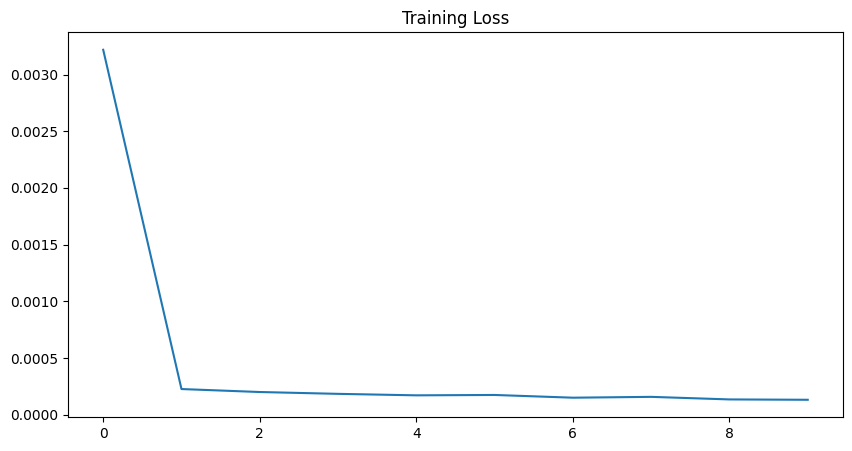

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.title("Training Loss")

plt.savefig("../outputs/plots/loss_curve.png")
plt.show()